# Synthetic-mode recovery with spectral-infill background

Background-signal counterpart of `result_initial_tests.ipynb`. Synthetic modes are recovered from the resolved-plus-background record, and spatial quality is measured relative to the background-derived similarity threshold produced by `result_background.ipynb`.

## Preamble

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Construct the synthetic suite and background-signal record

In [4]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# Construct the common synthetic suite and retain only the
# resolved-plus-background record used throughout this notebook.
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)
background_record_dict = {
    "background": record_dict_global["background"]
}


# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]
    

# Background-signal exact-DMD results

## Rank vs degree effects

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.7273484465985816e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.7781529084835856e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.7030511747239196e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.6854860715228824e+16. Consider preprocessing data, passing in augment

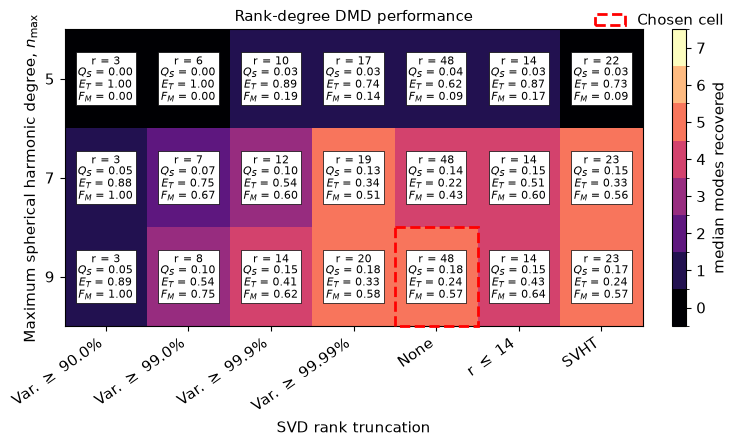

(<Figure size 725x435 with 2 Axes>,
 <Axes: title={'center': 'Rank-degree DMD performance'}, xlabel='SVD rank truncation', ylabel='Maximum spherical harmonic degree, $n_{\\max}$'>,
 <matplotlib.colorbar.Colorbar at 0x75359a1b3910>)

In [14]:

# nmax values to test
nmax_list = [5, 7, 9]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)


dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":50,
    "record_for_ensemble":"background"
}

Rank_Degree_Heatmap(background_record_dict, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings,
                    chosen_rank_degree=(-1, 9),
                    similarity_threshold_key="background",
                    )

## Uncertainty effects on optimal rank vs degree

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 422231.47173880273. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


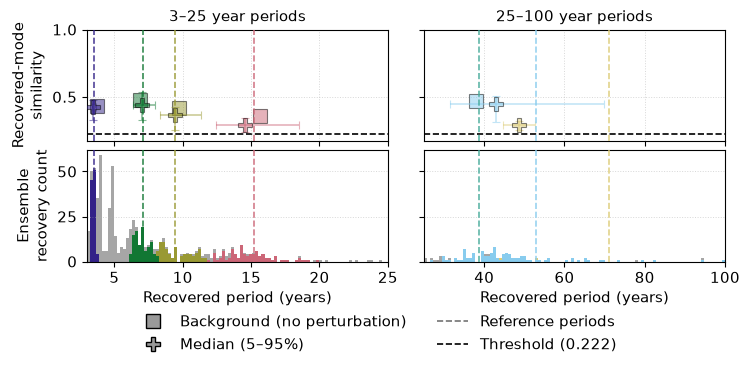

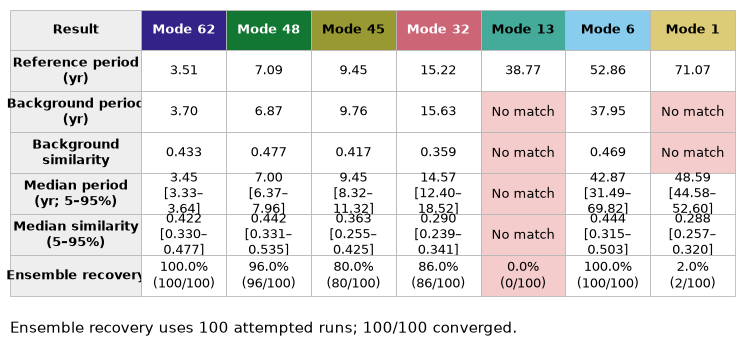

In [7]:


# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

nmax_choice = 9
svd_rank_choice = -1

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run(background_record_dict, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

similarity_threshold = similarity_thresholds["background"][str(nmax_choice)]

non_perturbed_record = "background"

similarity_figure, similarity_axes = Plot_Single_Run_Ensemble_Results(
    results_dict, syn_suite_info_global, total_unmatched_periods,
    similarity_threshold, record_markers, record_plotting_params,
    figure_width=text_width, non_perturbed_record=non_perturbed_record,
)

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    results_dict, syn_suite_info_global,
    non_perturbed_record=non_perturbed_record,
    ensemble_percentage_basis="attempted",
)
plt.show()

# Background-signal Hankel-DMD results

## Hankel embedding depth parameter test

In [15]:

nmax_choice = 9
svd_rank_choice = 0.999

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":50,
    "record_for_ensemble":"background"
}

hankel_d_list = [0, 2, 4, 6, 8, 10, 12, 14, 16]
#hankel_d_list = [0, 8, 9, 10, 11, 12]
num_d = len(hankel_d_list)
similarity_threshold = similarity_thresholds["background"][str(nmax_choice)]


# code to make heatmap - add into heatmap plotter at some point
d_match_results = {
    "median": np.zeros(num_d),
    "p95": np.zeros(num_d),
    "p05": np.zeros(num_d),
} 
background_non_perturbed_match_counts = np.zeros(num_d)

# initialising mode performance outcomes
mode_recovery_performance = {}

for mode_num in syn_suite_info_global:
    mode_recovery_performance[mode_num] = {
        "spatial_quality":np.zeros(num_d),
        "match_period_errors":np.ones(num_d),
        "runs_with_mode_match":np.zeros(num_d)
    }


# for each embedding d to be tested
for d_idx, embedding_d in enumerate(hankel_d_list):

    if embedding_d > 0:
        dmd_settings["hankel_flag"] = True
        dmd_settings["embedding_d"] = embedding_d


    # getting output of dmd for a run with a specific nmax, svd rank
    results_dict = Pipeline_Run(background_record_dict, syn_suite_info_global, 
            dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
            ensemble_settings=ensemble_settings)

    background_non_perturbed_match_counts[d_idx] = (
        results_dict["background"]["match_count"]
    )

    results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

    d_match_results["median"][d_idx] = results_dict["median"]["match_count"]["value"]
    d_match_results["p95"][d_idx] = results_dict["median"]["match_count"]["p95"]
    d_match_results["p05"][d_idx] = results_dict["median"]["match_count"]["p05"]

    # for each d - want the performance of each mode
    for mode_num in syn_suite_info_global:
        
        mode_results = results_dict["median"][mode_num]

        runs_with_match = mode_results["runs_with_mode_match"]
        mode_recovery_performance[mode_num]["runs_with_mode_match"][d_idx] = runs_with_match

        if runs_with_match > 0:
            median_similarity = mode_results["match_similarities"]["value"]
            spatial_quality = (
                (median_similarity - similarity_threshold)
                / (1 - similarity_threshold)
            )
            if not -1e-12 <= spatial_quality <= 1 + 1e-12:
                raise ValueError(
                    f"Invalid threshold-relative spatial quality "
                    f"{spatial_quality:.6f} for mode {mode_num}, "
                    f"embedding d={embedding_d}."
                )
            mode_recovery_performance[mode_num]["spatial_quality"][d_idx] = (
                np.clip(spatial_quality, 0.0, 1.0)
            )
            mode_recovery_performance[mode_num]["match_period_errors"][d_idx] = (
                mode_results["match_period_errors"]["value"]
            )
        else:
            # Match the missing-mode convention used by Rank_Degree_Heatmap.
            mode_recovery_performance[mode_num]["spatial_quality"][d_idx] = 0.0
            mode_recovery_performance[mode_num]["match_period_errors"][d_idx] = 1.0

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 422231.47173880273. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1427: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdim

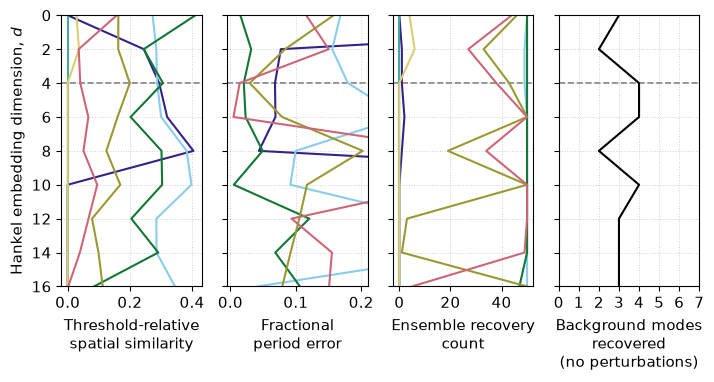

In [16]:
chosen_embedding_d = 4

embedding_figure, embedding_axes = Plot_Hankel_Embedding_Performance(
    hankel_d_list, mode_recovery_performance, syn_suite_info_global,
    non_perturbed_match_counts=background_non_perturbed_match_counts,
    figure_width=text_width, chosen_embedding_d=chosen_embedding_d,
    non_perturbed_record_label="Background",
)
plt.show()

## Uncertainty effects on optimal hankel choice

In [34]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":4,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

nmax_choice = 9
svd_rank_choice = -1

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run(background_record_dict, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

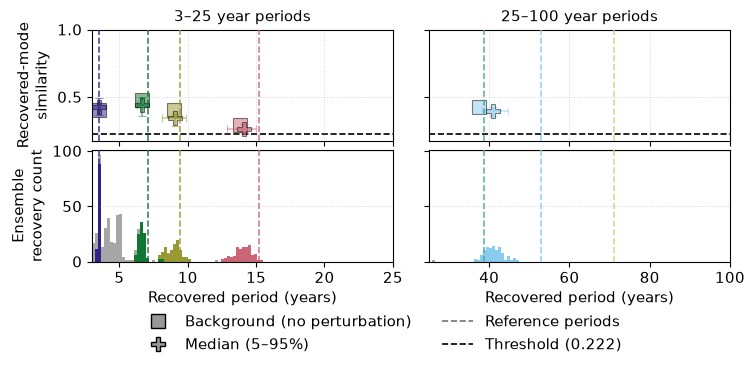

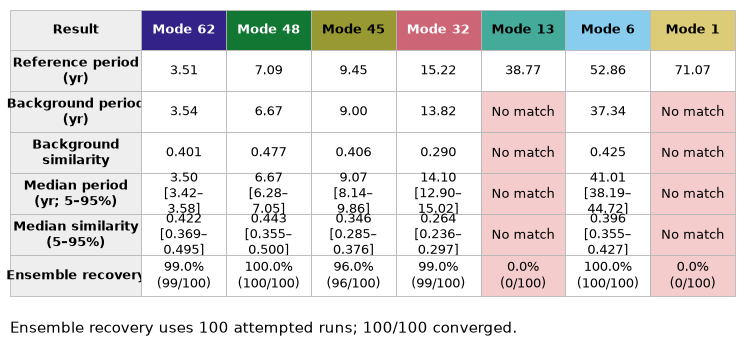

In [35]:
similarity_threshold = similarity_thresholds[
    "background"
][str(nmax_choice)]

non_perturbed_record = "background"

similarity_figure, similarity_axes = Plot_Single_Run_Ensemble_Results(
    results_dict, syn_suite_info_global, total_unmatched_periods,
    similarity_threshold, record_markers, record_plotting_params,
    figure_width=text_width, non_perturbed_record=non_perturbed_record,
)

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    results_dict, syn_suite_info_global,
    non_perturbed_record=non_perturbed_record,
    ensemble_percentage_basis="attempted",
)
plt.show()

## Effect of hankel on degree-rank choice

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 388518.9627309372. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1427: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims

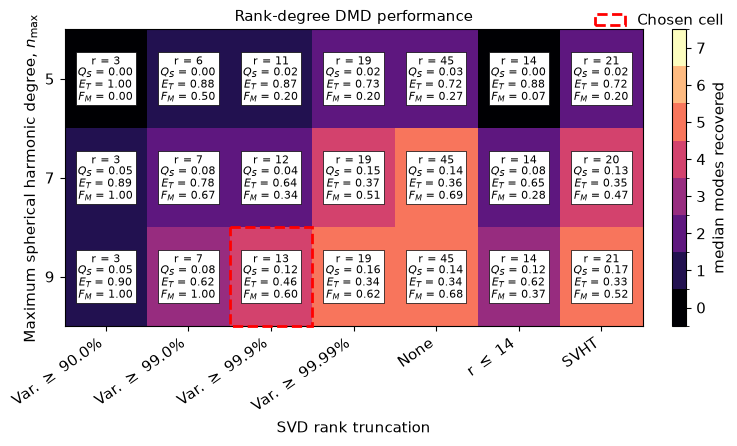

(<Figure size 725x435 with 2 Axes>,
 <Axes: title={'center': 'Rank-degree DMD performance'}, xlabel='SVD rank truncation', ylabel='Maximum spherical harmonic degree, $n_{\\max}$'>,
 <matplotlib.colorbar.Colorbar at 0x753599d4a1d0>)

In [15]:

# nmax values to test
nmax_list = [5, 7, 9]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":4,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"background"
}

Rank_Degree_Heatmap(background_record_dict, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings,
                    chosen_rank_degree=(0.999, 9),
                    similarity_threshold_key="background",
                    )